# 09 — Coste de adaptación: fine-tuning completo de Chronos-2 y TTM con todos los datos

**RESPIR-AI · TFG** — Completa la matriz de regímenes de entrenamiento: a los resultados previos
(Chronos-2 ZS y LoRA; TTM ZS y few-shot 5 %) se añaden **(A)** el fine-tuning COMPLETO de Chronos-2
(los 120.1 M de parámetros) en U y F con dos learning rates, y **(B)** TTM entrenado con el 20 % y el
100 % del train. Mismas 36 ventanas del protocolo v2, contexto 512 h, H ∈ {6,12,24,48}, semilla 42;
entrenamiento solo con train (validación para selección de checkpoint; test intacto). Contraste
**Diebold-Mariano con corrección HLN** (retardo Newey-West ⌈H/24⌉ por el solape entre orígenes).

Este cuaderno **re-ejecuta** los siete entrenamientos (~10 min en una RTX 3070) y comprueba que los
MAE reproducidos coinciden con `results/entrenamiento_completo.csv` a ±0,01.

In [1]:
# Raíz del repositorio como cwd (permite ejecutar desde notebooks/ o desde la raíz)
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings
import numpy as np, pandas as pd, torch
from chronos import Chronos2Pipeline
from chronos.chronos2 import preprocess as c2pre
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
from scipy import stats
import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
print("orígenes:", len(origins), "| Y:", Y.shape)

orígenes: 36 | Y: (36, 48)


## 1. Series de entrenamiento y validación por segmento

In [2]:
train_end_ts = pd.Timestamp(proto['particion']['train']['fin'])
val_start_ts = pd.Timestamp(proto['particion']['val']['inicio'])
val_end_ts   = pd.Timestamp(proto['particion']['val']['fin'])
def contiguous_series(mask):
    return [g for _, g in df[mask & (df.segment_id >= 0)].groupby('segment_id')]
tr_chunks = contiguous_series(df.index <= train_end_ts)
va_chunks = contiguous_series((df.index >= val_start_ts) & (df.index <= val_end_ts))
print("chunks train:", [(int(g.segment_id.iloc[0]), len(g)) for g in tr_chunks])
print("chunks val:", [(int(g.segment_id.iloc[0]), len(g)) for g in va_chunks])

chunks train: [(0, 491), (1, 413), (2, 1347), (3, 634), (4, 2171), (5, 676), (6, 451), (7, 988), (8, 531), (9, 695), (10, 1101), (11, 106)]
chunks val: [(11, 283), (12, 1089)]


## 2. Full fine-tuning de Chronos-2

La API pública lo soporta directamente: `Chronos2Pipeline.fit(..., finetune_mode='full')`
(firma `Literal['full','lora']`). Config: 500 pasos, batch 32, contexto 512, lr ∈ {5e-6, 2e-6}
(el segundo tras observar inestabilidad con el primero: la pérdida de validación empeora tras
~200 pasos con grad_norm ≈ 55). El Trainer restaura el mejor checkpoint según validación.

In [3]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
n_params_c2 = sum(p.numel() for p in pipe.model.parameters())

def ft_inputs_cov(chunks, cov):
    dicts = []
    for g in chunks:
        if len(g) < 96: continue
        d = {"target": g['our'].to_numpy(dtype=np.float32)}
        if cov == "F":
            d["past_covariates"] = {c: g[c].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    return dicts

def full_ft(cov, lr):
    tr = ft_inputs_cov(tr_chunks, cov); va = ft_inputs_cov(va_chunks, cov)
    if cov == "F":
        tr = c2pre.from_list_of_dicts(tr, prediction_length=48, known_covariates_names=METEO)
        va = c2pre.from_list_of_dicts(va, prediction_length=48, known_covariates_names=METEO)
    torch.manual_seed(42); np.random.seed(42)
    torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    pipe_ft = pipe.fit(tr, prediction_length=48, validation_inputs=va,
                       finetune_mode="full", learning_rate=lr, num_steps=500,
                       context_length=512, batch_size=32, output_dir=f"c2_full_{cov}",
                       remove_printer_callback=True, logging_strategy="no")
    return pipe_ft, time.perf_counter()-t0, torch.cuda.max_memory_allocated()/1e6

def eval_c2(pipeline, cov, etiqueta, extra=None):
    dicts = []
    for o in origins:
        i = o['iloc']
        d = {"target": df['our'].iloc[i-511:i+1].to_numpy(dtype=np.float32)}
        if cov == "F":
            d["past_covariates"] = {c: df[c].iloc[i-511:i+1].to_numpy(dtype=np.float32) for c in METEO}
            d["future_covariates"] = {c: df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in METEO}
        dicts.append(d)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    qs, means = pipeline.predict_quantiles(dicts, prediction_length=48)
    torch.cuda.synchronize()
    t_inf = (time.perf_counter()-t0)/36
    P = np.stack([m.squeeze().numpy() for m in means]).astype(float)
    ex = {"covariables": cov, "n_ventanas": 36}
    if extra: ex.update(extra)
    return evaluate_preds(P, Y, "chronos2", etiqueta, t_inf, 512, origins, extra=ex)

Loading weights: 100%|##########| 170/170 [00:00<00:00, 174.38it/s]


In [4]:
all_rows, all_wins = [], []
for cov, lr, esc in [("U", 5e-6, "full_C512_U"), ("U", 2e-6, "full_C512_U_lr2e6"),
                     ("F", 5e-6, "full_C512_F"), ("F", 2e-6, "full_C512_F_lr2e6")]:
    pipe_ft, t_ft, mem_ft = full_ft(cov, lr)
    rows, wins = eval_c2(pipe_ft, cov, esc, {"regimen": "full", "lr": lr})
    for r in rows: r.update({"t_train_s": t_ft, "vram_gb": mem_ft/1000, "params_entrenados": n_params_c2})
    all_rows += rows; all_wins += wins
    print(f"{esc}: MAE@6/24/48 = {[round(r['MAE'],3) for r in rows if r['H'] in (6,24,48)]} "
          f"| {t_ft:.0f} s | {mem_ft/1000:.2f} GB")
    del pipe_ft; torch.cuda.empty_cache()

{'eval_loss': '10.14', 'eval_runtime': '0.0909', 'eval_samples_per_second': '22.01', 'eval_steps_per_second': '11.01', 'epoch': '0.2'}
{'eval_loss': '10.07', 'eval_runtime': '0.0572', 'eval_samples_per_second': '34.99', 'eval_steps_per_second': '17.5', 'epoch': '0.4'}
{'eval_loss': '10.55', 'eval_runtime': '0.0715', 'eval_samples_per_second': '27.97', 'eval_steps_per_second': '13.99', 'epoch': '0.6'}
{'eval_loss': '10.55', 'eval_runtime': '0.0433', 'eval_samples_per_second': '46.21', 'eval_steps_per_second': '23.11', 'epoch': '0.8'}
{'loss': '6.766', 'grad_norm': '55.12', 'learning_rate': '1e-08', 'epoch': '1'}
{'eval_loss': '10.6', 'eval_runtime': '0.0304', 'eval_samples_per_second': '65.81', 'eval_steps_per_second': '32.91', 'epoch': '1'}
{'train_runtime': '52.5', 'train_samples_per_second': '304.8', 'train_steps_per_second': '9.524', 'train_loss': '6.766', 'epoch': '1'}
full_C512_U: MAE@6/24/48 = [3.901, 4.596, 5.209] | 57 s | 3.23 GB
{'eval_loss': '10.17', 'eval_runtime': '0.0424',

Writing model shards: 100%|##########| 1/1 [00:00<00:00,  3.04it/s]


## 3. TTM: few-shot 20 % y 100 % del train (U y F)

Mismo pipeline del cuaderno 05 (AdamW lr=1e-4, early stopping en validación, paciencia 5, máx. 50 épocas); cambia el subconjunto de ventanas (semilla 42). El modelo con covariables usa `mix_channel` + canales exógenos de meteo con *forecast channel mixing*.

In [5]:
TTM_ID = "ibm-granite/granite-timeseries-ttm-r2"
DEV = "cuda"
CHANNELS = ['our'] + PROC + METEO
Xall = df[CHANNELS].to_numpy(dtype=np.float32)
meteo_idx = [CHANNELS.index(c) for c in METEO]
cols_by_cov = {"U": [0], "F": [0] + meteo_idx}

WIN = 512 + 96
def window_starts(chunks):
    starts = []
    for g in chunks:
        i0 = df.index.get_loc(g.index[0])
        starts.extend(range(i0, i0 + len(g) - WIN + 1))
    return np.array(starts)
tr_all = window_starts(tr_chunks)
va_starts = window_starts(va_chunks)[::4]

def make_tensors(starts, cols):
    past = np.stack([Xall[s:s+512][:, cols] for s in starts])
    fut  = np.stack([Xall[s+512:s+608][:, cols] for s in starts])
    return torch.tensor(past), torch.tensor(fut)

def load_ttm(cov):
    cols = cols_by_cov[cov]
    kw = {}
    if len(cols) > 1:
        ex_idx = sorted(cols.index(ci) for ci in cols if ci in meteo_idx)
        kw = dict(num_input_channels=len(cols), decoder_mode="mix_channel",
                  prediction_channel_indices=[0], exogenous_channel_indices=ex_idx,
                  enable_forecast_channel_mixing=True, fcm_context_length=5,
                  fcm_use_mixer=True, fcm_prepend_past=True, ignore_mismatched_sizes=True)
    return TinyTimeMixerForPrediction.from_pretrained(TTM_ID, **kw), cols

def finetune_ttm(model, cols, starts, max_epochs=50, patience=5, lr=1e-4, batch=64):
    torch.manual_seed(42); np.random.seed(42)
    Xtr, Ytr = make_tensors(starts, cols); Xva, Yva = make_tensors(va_starts, cols)
    model = model.to(DEV)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    best, best_state, bad = np.inf, None, 0
    torch.cuda.reset_peak_memory_stats(); t0 = time.perf_counter()
    for ep in range(max_epochs):
        model.train()
        perm = torch.randperm(Xtr.shape[0])
        for k in range(0, Xtr.shape[0], batch):
            idx = perm[k:k+batch]
            out = model(past_values=Xtr[idx].to(DEV), future_values=Ytr[idx].to(DEV), return_loss=True)
            opt.zero_grad(); out.loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = float(model(past_values=Xva.to(DEV), future_values=Yva.to(DEV), return_loss=True).loss)
        if vl < best - 1e-5: best, bad, best_state = vl, 0, {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state)
    return model, time.perf_counter()-t0, torch.cuda.max_memory_allocated()/1e6, ep+1

def infer_ttm(model, cols, use_fut):
    past = torch.tensor(np.stack([Xall[o['iloc']-511:o['iloc']+1][:, cols] for o in origins]))
    fut = None
    if use_fut:
        f = np.zeros((36, 96, len(cols)), dtype=np.float32)
        for w, o in enumerate(origins):
            for j, ci in enumerate(cols):
                if ci in meteo_idx: f[w, :, j] = Xall[o['iloc']+1:o['iloc']+97, ci]
        fut = torch.tensor(f)
    model = model.to(DEV).eval()
    torch.cuda.synchronize(); t0 = time.perf_counter()
    with torch.no_grad():
        out = model(past_values=past.to(DEV), future_values=fut.to(DEV) if fut is not None else None, return_loss=False)
    torch.cuda.synchronize()
    return out.prediction_outputs[..., 0].float().cpu().numpy()[:, :48], (time.perf_counter()-t0)/36

In [6]:
rng = np.random.default_rng(42)
subsets = {"100pct": tr_all, "20pct": rng.choice(tr_all, size=int(0.20*len(tr_all)), replace=False)}
for tag, covs in [("100pct", ["U", "F"]), ("20pct", ["F"])]:
    for cov in covs:
        m, cols = load_ttm(cov)
        m, t_ft, mem, ep = finetune_ttm(m, cols, subsets[tag])
        n_tr = sum(p.numel() for p in m.parameters())
        P, t_inf = infer_ttm(m, cols, cov == "F")
        rows, wins = evaluate_preds(P, Y, "ttm", f"ft{tag}_{cov}", t_inf, 512, origins,
                                    extra={"covariables": cov, "n_ventanas": 36, "regimen": f"ft_{tag}"})
        for r in rows: r.update({"t_train_s": t_ft, "vram_gb": mem/1000, "params_entrenados": n_tr, "epocas": ep})
        all_rows += rows; all_wins += wins
        print(f"ttm ft{tag}_{cov}: MAE@6/24/48 = {[round(r['MAE'],3) for r in rows if r['H'] in (6,24,48)]} "
              f"| {ep} ép., {t_ft:.1f} s")
        del m; torch.cuda.empty_cache()
del pipe; torch.cuda.empty_cache()

ttm ft100pct_U: MAE@6/24/48 = [3.596, 3.946, 4.428] | 6 ép., 4.5 s
ttm ft100pct_F: MAE@6/24/48 = [3.521, 3.934, 4.425] | 7 ép., 13.5 s
ttm ft20pct_F: MAE@6/24/48 = [3.904, 4.248, 4.737] | 19 ép., 7.9 s


Loading weights: 100%|##########| 134/134 [00:00<00:00, 2915.98it/s]


## 4. Verificación de reproducibilidad contra el CSV publicado

Los MAE re-ejecutados deben coincidir con `results/entrenamiento_completo.csv` a ±0,01 (misma semilla, mismo hardware).

In [7]:
res_new = pd.DataFrame(all_rows).rename(columns={"t_inferencia_s": "t_inf_s"})
CSV = "results/entrenamiento_completo.csv"
if os.path.exists(CSV):
    prev = pd.read_csv(CSV)
    m = res_new.merge(prev[["escenario", "H", "MAE"]], on=["escenario", "H"], suffixes=("", "_prev"))
    m["dif"] = (m.MAE - m.MAE_prev).abs()
    print(m[["escenario", "H", "MAE", "MAE_prev", "dif"]].round(4).to_string(index=False))
    print(f"\ndesviación máxima: {m.dif.max():.5f}")
    assert m.dif.max() <= 0.01, "la re-ejecución NO reproduce el CSV a ±0,01"
    print("OK: reproducido a ±0,01")
cols_out = ["modelo","regimen","covariables","H","MAE","RMSE","MAPE","R2","t_train_s","vram_gb","params_entrenados","t_inf_s","escenario","lr"]
res_new[[c for c in cols_out if c in res_new.columns]].to_csv(CSV, index=False)
print("escrito", CSV)

        escenario  H    MAE  MAE_prev  dif
      full_C512_U  6 3.9009    3.9009  0.0
      full_C512_U 12 4.2834    4.2834  0.0
      full_C512_U 24 4.5960    4.5960  0.0
      full_C512_U 48 5.2085    5.2085  0.0
full_C512_U_lr2e6  6 3.9381    3.9381  0.0
full_C512_U_lr2e6 12 4.2902    4.2902  0.0
full_C512_U_lr2e6 24 4.5292    4.5292  0.0
full_C512_U_lr2e6 48 5.1457    5.1457  0.0
      full_C512_F  6 3.7017    3.7017  0.0
      full_C512_F 12 4.0466    4.0466  0.0
      full_C512_F 24 4.1167    4.1167  0.0
      full_C512_F 48 4.4715    4.4715  0.0
full_C512_F_lr2e6  6 3.6297    3.6297  0.0
full_C512_F_lr2e6 12 3.9585    3.9585  0.0
full_C512_F_lr2e6 24 4.0245    4.0245  0.0
full_C512_F_lr2e6 48 4.3679    4.3679  0.0
       ft100pct_U  6 3.5958    3.5958  0.0
       ft100pct_U 12 3.8462    3.8462  0.0
       ft100pct_U 24 3.9458    3.9458  0.0
       ft100pct_U 48 4.4278    4.4278  0.0
       ft100pct_F  6 3.5209    3.5209  0.0
       ft100pct_F 12 3.8154    3.8154  0.0
       ft10

## 5. Diebold-Mariano (HLN) contra las referencias ZS / LoRA / few-shot 5 %

In [8]:
def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

prev_win = pd.read_parquet("results/errores_por_ventana_barrido.parquet")
win_new = pd.DataFrame(all_wins)
comparaciones = [("full_C512_U_lr2e6", "zs_C512_U"), ("full_C512_U_lr2e6", "ft_C512_U"),
                 ("full_C512_F_lr2e6", "zs_C512_F"), ("full_C512_F_lr2e6", "ft_C512_F"),
                 ("ft100pct_U", "zs_U"), ("ft100pct_U", "ft5_U"), ("ft100pct_F", "ft5_F")]
dm_rows = []
for esc_new, esc_ref in comparaciones:
    for H in [6, 24, 48]:
        a = win_new[(win_new.escenario==esc_new) & (win_new.H==H)].sort_values("ventana").MAE.to_numpy()
        b = prev_win[(prev_win.escenario==esc_ref) & (prev_win.H==H)].sort_values("ventana").MAE.to_numpy()
        s, p = dm_hln(a - b, h=max(1, int(np.ceil(H/24))))
        dm_rows.append({"nueva": esc_new, "referencia": esc_ref, "H": H,
                        "MAE_nueva": round(a.mean(),3), "MAE_ref": round(b.mean(),3),
                        "DM_stat": round(s,3), "p_valor": round(p,4)})
df_dm = pd.DataFrame(dm_rows)
df_dm.to_csv("results/dm_entrenamiento.csv", index=False)
print(df_dm.to_string(index=False))

            nueva referencia  H  MAE_nueva  MAE_ref  DM_stat  p_valor
full_C512_U_lr2e6  zs_C512_U  6      3.938    3.631    2.706   0.0104
full_C512_U_lr2e6  zs_C512_U 24      4.529    4.119    2.549   0.0153
full_C512_U_lr2e6  zs_C512_U 48      5.146    4.535    2.302   0.0274
full_C512_U_lr2e6  ft_C512_U  6      3.938    3.658    2.788   0.0085
full_C512_U_lr2e6  ft_C512_U 24      4.529    4.027    3.361   0.0019
full_C512_U_lr2e6  ft_C512_U 48      5.146    4.474    2.791   0.0085
full_C512_F_lr2e6  zs_C512_F  6      3.630    3.640   -0.112   0.9113
full_C512_F_lr2e6  zs_C512_F 24      4.025    3.910    1.129   0.2665
full_C512_F_lr2e6  zs_C512_F 48      4.368    4.095    1.553   0.1294
full_C512_F_lr2e6  ft_C512_F  6      3.630    3.626    0.056   0.9555
full_C512_F_lr2e6  ft_C512_F 24      4.025    3.933    1.204   0.2367
full_C512_F_lr2e6  ft_C512_F 48      4.368    4.125    1.553   0.1294
       ft100pct_U       zs_U  6      3.596    3.676   -0.975   0.3364
       ft100pct_U   

**Lectura**: el full FT univariante es *significativamente peor* que su zero-shot y que su LoRA
en los tres horizontes (p ≤ 0.027). Ninguna otra comparación alcanza significación al 5 %: el full F
degrada de forma no significativa y las diferencias del TTM 100 % frente al 5 % son compatibles con
ruido. La adaptación ligera (LoRA / few-shot 5 %) es el punto dulce; el full FT es la única
configuración del estudio que empeora significativamente respecto a no entrenar — con ~9 600 h de
una sola planta, actualizar 120 M de parámetros erosiona el conocimiento preentrenado (olvido
catastrófico) que el LoRA preserva congelando el tronco.

## 6. Actualización del parquet por ventana (idempotente) y figura

In [9]:
PARQ = "results/errores_por_ventana_barrido.parquet"
win_new2 = win_new.copy(); win_new2["relleno"] = "contiguo"
prev = prev_win[~prev_win.escenario.isin(win_new2.escenario.unique())]
pd.concat([prev, win_new2], ignore_index=True).to_parquet(PARQ, index=False)
print("parquet actualizado:", len(prev), "+", len(win_new2))

parquet actualizado: 9524 + 1008


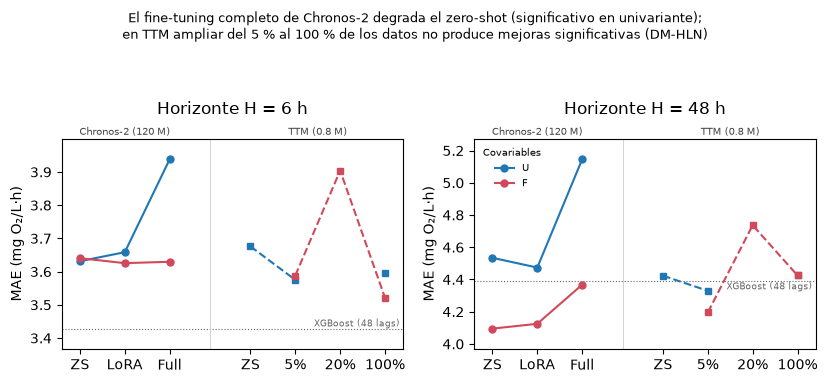

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

g48 = res_new[res_new.H==48].set_index("escenario").MAE
g6  = res_new[res_new.H==6].set_index("escenario").MAE
bar = pd.read_csv("results/barrido_contexto.csv")
ref = lambda esc, H: float(bar[(bar.escenario==esc) & (bar.H==H)].MAE.iloc[0])
base = pd.read_csv("results/resultados_baseline.csv")
xgb = lambda H: float(base[(base.escenario=="E1_univariante") & (base.H==H)].MAE.iloc[0])

c2 = {"U": {"ZS": ref("zs_C512_U",48), "LoRA": ref("ft_C512_U",48), "Full": g48["full_C512_U_lr2e6"]},
      "F": {"ZS": ref("zs_C512_F",48), "LoRA": ref("ft_C512_F",48), "Full": g48["full_C512_F_lr2e6"]}}
c2_h6 = {"U": {"ZS": ref("zs_C512_U",6), "LoRA": ref("ft_C512_U",6), "Full": g6["full_C512_U_lr2e6"]},
         "F": {"ZS": ref("zs_C512_F",6), "LoRA": ref("ft_C512_F",6), "Full": g6["full_C512_F_lr2e6"]}}
ttm = {"U": {"ZS": ref("zs_U",48), "5%": ref("ft5_U",48), "100%": g48["ft100pct_U"]},
       "F": {"5%": ref("ft5_F",48), "20%": g48["ft20pct_F"], "100%": g48["ft100pct_F"]}}
ttm_h6 = {"U": {"ZS": ref("zs_U",6), "5%": ref("ft5_U",6), "100%": g6["ft100pct_U"]},
          "F": {"5%": ref("ft5_F",6), "20%": g6["ft20pct_F"], "100%": g6["ft100pct_F"]}}

col_u, col_f = "#1f77b4", "#d1495b"
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.5))
def panel(ax, dc2, dttm, xref, H):
    regs_c2, regs_ttm = ["ZS","LoRA","Full"], ["ZS","5%","20%","100%"]
    x1 = np.arange(3); x2 = np.arange(4) + 3.8
    for cov, col in [("U", col_u), ("F", col_f)]:
        ax.plot(x1, [dc2[cov].get(r, np.nan) for r in regs_c2], "o-", color=col, ms=5,
                label=cov if H==48 else None)
        ax.plot(x2, [dttm.get(cov, {}).get(r, np.nan) for r in regs_ttm], "s--", color=col, ms=5)
    ax.axhline(xref, color="#666666", lw=0.8, ls=":")
    ax.annotate("XGBoost (48 lags)", xy=(0.99, xref), xycoords=("axes fraction","data"),
                ha="right", va="top" if H==48 else "bottom", fontsize=6.5, color="#666666")
    ax.set_xticks(list(x1)+list(x2)); ax.set_xticklabels(regs_c2+regs_ttm)
    ax.axvline(2.9, color="#cccccc", lw=0.6)
    ax.annotate("Chronos-2 (120 M)", xy=(1, 1.02), xycoords=("data","axes fraction"), ha="center", fontsize=7, color="#444444")
    ax.annotate("TTM (0.8 M)", xy=(5.3, 1.02), xycoords=("data","axes fraction"), ha="center", fontsize=7, color="#444444")
    ax.set_ylabel("MAE (mg O₂/L·h)"); ax.set_title(f"Horizonte H = {H} h", pad=18)
    ax.margins(x=0.06, y=0.12)
panel(axes[0], c2_h6, ttm_h6, xgb(6), 6)
panel(axes[1], c2, ttm, xgb(48), 48)
axes[1].legend(frameon=False, fontsize=7, loc="upper left", title="Covariables", title_fontsize=7)
fig.suptitle("El fine-tuning completo de Chronos-2 degrada el zero-shot (significativo en univariante);\n"
             "en TTM ampliar del 5 % al 100 % de los datos no produce mejoras significativas (DM-HLN)", fontsize=9, y=1.08)
fig.tight_layout()
fig.savefig("figures/fig_coste_adaptacion.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Conclusión

Ver `resumen_entrenamiento.md`. El orden de preferencia en Chronos-2 queda ZS+F ≥ LoRA+F > full; en TTM, el few-shot 5 % captura toda la mejora disponible. El margen restante no está en más entrenamiento sino en las covariables (meteo futura) y en la elección del contexto (cuadernos 07-08).